# Unidad 3: Búsqueda, Optimización y Agentes Inteligentes
## ♟️ Búsqueda Adversaria — Minimax y Alpha-Beta Pruning
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/search/03_BusquedaAdversaria.ipynb)

---

### 🎯 Objetivos
- Entender el modelo de **juegos de suma cero** de dos jugadores.
- Implementar el algoritmo **Minimax** y comprender el árbol de juego.
- Aplicar **Alpha-Beta Pruning** para reducir drásticamente los nodos explorados.
- Comparar el rendimiento de ambos algoritmos sobre **Tic-Tac-Toe (Tateti)**.

---

### 📖 Teoría

En los juegos de dos jugadores competitivos (suma cero), cada jugador toma turnos alternando decisiones. Se modela con:

- **MAX**: el agente que queremos maximizar (p. ej. nosotros).
- **MIN**: el oponente, que intenta minimizar el resultado de MAX.
- **Utilidad**: valor numérico en los estados terminales (+1 = MAX gana, −1 = MIN gana, 0 = empate).

**Minimax** explora el árbol de juego completo y selecciona el movimiento óptimo asumiendo que el oponente también juega de forma óptima:

$$
\text{minimax}(s) = \begin{cases}
\text{utility}(s) & \text{si } s \text{ es terminal} \\
\max_{a} \text{minimax}(\text{result}(s,a)) & \text{si es turno de MAX} \\
\min_{a} \text{minimax}(\text{result}(s,a)) & \text{si es turno de MIN}
\end{cases}
$$

**Alpha-Beta Pruning** agrega dos parámetros:
- **α** (alpha): el mejor valor que MAX puede garantizar en el camino actual.
- **β** (beta): el mejor valor que MIN puede garantizar en el camino actual.

Cuando β ≤ α se poda la rama: explorar esos nodos no cambia la decisión.
En el **mejor caso**, Alpha-Beta reduce la complejidad de $O(b^d)$ a $O(b^{d/2})$.

## 📦 Paso 1: Importaciones

In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import display
import pandas as pd

random.seed(42)
print("✅ Librerías listas")

✅ Librerías listas


## 🎲 Paso 2: Representación del juego Tic-Tac-Toe

El estado es un **string de 9 caracteres** que representa el tablero 3×3:
- `'X'` = jugador MAX (jugador 1)
- `'O'` = jugador MIN (jugador 2)
- `'.'` = celda vacía

```
 0 | 1 | 2
-----------
 3 | 4 | 5
-----------
 6 | 7 | 8
```

In [2]:
# ============================================================
# Tic-Tac-Toe: estado, movimientos, terminal, utilidad
# ============================================================

EMPTY   = '.' * 9          # tablero vacío
WIN_LINES = [
    (0,1,2), (3,4,5), (6,7,8),  # filas
    (0,3,6), (1,4,7), (2,5,8),  # columnas
    (0,4,8), (2,4,6)             # diagonales
]

def display_board(state, label=""):
    """Imprime el tablero de forma legible."""
    if label:
        print(f"  {label}")
    print(f" {state[0]} | {state[1]} | {state[2]} ")
    print("-----------")
    print(f" {state[3]} | {state[4]} | {state[5]} ")
    print("-----------")
    print(f" {state[6]} | {state[7]} | {state[8]} ")
    print()

def winner(state):
    """Retorna 'X', 'O' o None."""
    for a, b, c in WIN_LINES:
        if state[a] == state[b] == state[c] != '.':
            return state[a]
    return None

def is_terminal(state):
    """True si el juego terminó (alguien ganó o tablero lleno)."""
    return winner(state) is not None or '.' not in state

def get_moves(state):
    """Lista de posiciones vacías disponibles."""
    return [i for i, c in enumerate(state) if c == '.']

def apply_move(state, pos, player):
    """Aplica un movimiento y retorna el nuevo estado."""
    s = list(state)
    s[pos] = player
    return ''.join(s)

def utility(state):
    """Utilidad del estado terminal: +1 X gana, -1 O gana, 0 empate."""
    w = winner(state)
    return 1 if w == 'X' else (-1 if w == 'O' else 0)

# Demo
demo = apply_move(apply_move(apply_move(EMPTY, 4, 'X'), 0, 'O'), 8, 'X')
display_board(demo, "Estado de ejemplo")
print(f"Terminal: {is_terminal(demo)} | Ganador: {winner(demo)} | Movimientos disponibles: {get_moves(demo)}")

  Estado de ejemplo
 O | . | . 
-----------
 . | X | . 
-----------
 . | . | X 

Terminal: False | Ganador: None | Movimientos disponibles: [1, 2, 3, 5, 6, 7]


## 🤖 Paso 3: Algoritmo Minimax

El algoritmo recorre el árbol de juego completo de forma **recursiva**. El parámetro `counter` contabiliza cuántos nodos se visitan.

In [3]:
def minimax(state, maximize, counter):
    """
    Minimax recursivo.
    Args:
        state   : estado actual del juego
        maximize: True si es turno de MAX (X), False si es turno de MIN (O)
        counter : lista de un elemento [int] para contar nodos visitados
    Returns:
        (value, best_move) — mejor valor y movimiento correspondiente
    """
    counter[0] += 1

    if is_terminal(state):
        return utility(state), None

    player = 'X' if maximize else 'O'
    ms = get_moves(state)

    if maximize:
        best_val, best_move = float('-inf'), None
        for m in ms:
            val, _ = minimax(apply_move(state, m, player), False, counter)
            if val > best_val:
                best_val, best_move = val, m
        return best_val, best_move
    else:
        best_val, best_move = float('inf'), None
        for m in ms:
            val, _ = minimax(apply_move(state, m, player), True, counter)
            if val < best_val:
                best_val, best_move = val, m
        return best_val, best_move


# Demo: mejor primer movimiento desde tablero vacío
counter_mm = [0]
val_mm, move_mm = minimax(EMPTY, True, counter_mm)

print("=== Minimax desde tablero vacío ===")
print(f"  Valor esperado : {val_mm}  (0 = empate con juego perfecto)")
print(f"  Movimiento sugerido: posición {move_mm}")
print(f"  Nodos explorados   : {counter_mm[0]:,}")

=== Minimax desde tablero vacío ===
  Valor esperado : 0  (0 = empate con juego perfecto)
  Movimiento sugerido: posición 0
  Nodos explorados   : 549,946


## ✂️ Paso 4: Alpha-Beta Pruning

Se añaden los parámetros **α** y **β** para evitar explorar ramas que no pueden influir en la decisión final.

La lógica de poda:
- En nodo MAX: si `best_val ≥ β` → **poda beta** (MIN ya tiene algo mejor arriba).
- En nodo MIN: si `best_val ≤ α` → **poda alfa** (MAX ya tiene algo mejor arriba).

In [4]:
def alphabeta(state, maximize, alpha, beta, counter):
    """
    Minimax con Alpha-Beta Pruning.
    Args:
        alpha: mejor valor que MAX puede garantizar en este camino
        beta : mejor valor que MIN puede garantizar en este camino
    """
    counter[0] += 1

    if is_terminal(state):
        return utility(state), None

    player = 'X' if maximize else 'O'
    ms = get_moves(state)

    if maximize:
        best_val, best_move = float('-inf'), None
        for m in ms:
            val, _ = alphabeta(apply_move(state, m, player), False, alpha, beta, counter)
            if val > best_val:
                best_val, best_move = val, m
            alpha = max(alpha, best_val)
            if beta <= alpha:          # poda beta
                break
        return best_val, best_move
    else:
        best_val, best_move = float('inf'), None
        for m in ms:
            val, _ = alphabeta(apply_move(state, m, player), True, alpha, beta, counter)
            if val < best_val:
                best_val, best_move = val, m
            beta = min(beta, best_val)
            if beta <= alpha:          # poda alfa
                break
        return best_val, best_move


# Demo
counter_ab = [0]
val_ab, move_ab = alphabeta(EMPTY, True, float('-inf'), float('inf'), counter_ab)

print("=== Alpha-Beta desde tablero vacío ===")
print(f"  Valor esperado : {val_ab}")
print(f"  Movimiento sugerido: posición {move_ab}")
print(f"  Nodos explorados   : {counter_ab[0]:,}")
print()
print("=== Comparación ===")
reduccion = (1 - counter_ab[0] / counter_mm[0]) * 100
print(f"  Minimax   : {counter_mm[0]:,} nodos")
print(f"  Alpha-Beta: {counter_ab[0]:,} nodos")
print(f"  Reducción : {reduccion:.1f}% menos nodos explorados")

=== Alpha-Beta desde tablero vacío ===
  Valor esperado : 0
  Movimiento sugerido: posición 0
  Nodos explorados   : 18,297

=== Comparación ===
  Minimax   : 549,946 nodos
  Alpha-Beta: 18,297 nodos
  Reducción : 96.7% menos nodos explorados


## 📊 Paso 5: Comparativa por profundidad del juego

Comparamos los nodos explorados según cuántas celdas están ya ocupadas (mayor ocupación = menor profundidad restante).

                     Posición  Minimax  Alpha-Beta Reducción %
0 movimientos (tablero vacío)   549946       18297       96.7%
       1 movimiento realizado    59705        2338       96.1%
     2 movimientos realizados     8232         749       90.9%
     3 movimientos realizados     1349         336       75.1%
     4 movimientos realizados      234          65       72.2%
     5 movimientos realizados       41          32       22.0%


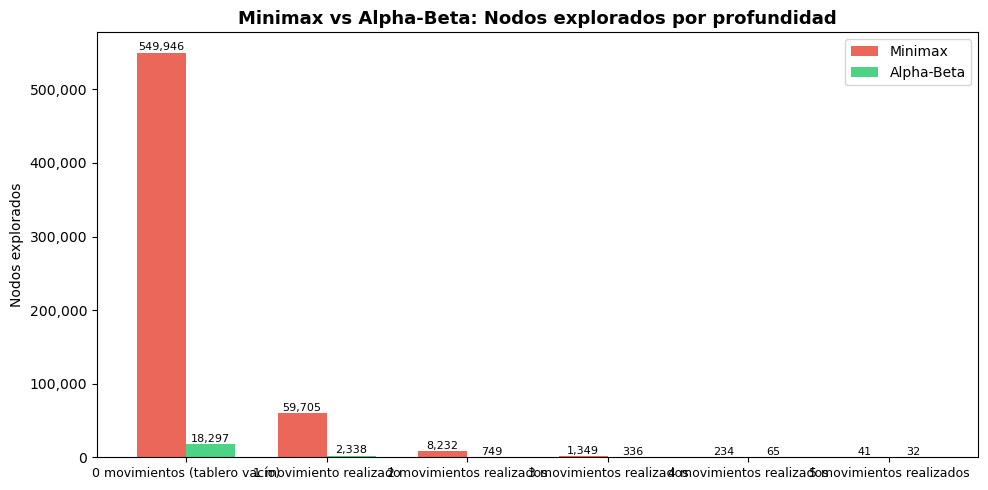

In [5]:
# Posiciones de prueba con distinta profundidad restante
test_positions = [
    (EMPTY,            "0 movimientos\n(tablero vacío)"),
    ('X........',      "1 movimiento\nrealizado"),
    ('XO.......',      "2 movimientos\nrealizados"),
    ('XOX......',      "3 movimientos\nrealizados"),
    ('XOXO.....',      "4 movimientos\nrealizados"),
    ('XOXOX....',      "5 movimientos\nrealizados"),
]

resultados = []
for state, label in test_positions:
    # Verificar que no sea terminal
    if is_terminal(state):
        continue
    is_x_turn = state.count('X') == state.count('O')
    c_mm, c_ab = [0], [0]
    minimax(state, is_x_turn, c_mm)
    alphabeta(state, is_x_turn, float('-inf'), float('inf'), c_ab)
    resultados.append({
        'Posición': label.replace('\n', ' '),
        'Minimax': c_mm[0],
        'Alpha-Beta': c_ab[0],
        'Reducción %': f"{(1 - c_ab[0]/c_mm[0])*100:.1f}%"
    })

df = pd.DataFrame(resultados)
print(df.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df))
w = 0.35
bars_mm = ax.bar(x - w/2, df['Minimax'],    w, label='Minimax',     color='#e74c3c', alpha=0.85)
bars_ab = ax.bar(x + w/2, df['Alpha-Beta'], w, label='Alpha-Beta',  color='#2ecc71', alpha=0.85)

for bar in bars_mm:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{bar.get_height():,}", ha='center', va='bottom', fontsize=8)
for bar in bars_ab:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{bar.get_height():,}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df['Posición'], fontsize=9)
ax.set_ylabel('Nodos explorados')
ax.set_title('Minimax vs Alpha-Beta: Nodos explorados por profundidad', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))
plt.tight_layout()
plt.show()

## 🎮 Paso 6: Demo — IA vs Jugador Aleatorio

La IA usa **Alpha-Beta** (juego perfecto). El oponente elige movimientos al azar.

In [8]:
def ai_move(state, ai_player):
    """La IA elige el mejor movimiento usando Alpha-Beta."""
    counter = [0]
    maximize = (ai_player == 'X')
    _, move = alphabeta(state, maximize, float('-inf'), float('inf'), counter)
    return move

def random_move(state):
    """Jugador aleatorio."""
    return random.choice(get_moves(state))

def play_game(ai_player='X', verbose=True):
    """Simula una partida completa: IA vs Aleatorio."""
    state  = EMPTY
    human  = 'O' if ai_player == 'X' else 'X'
    turn   = 'X'  # X siempre empieza

    if verbose:
        print(f"IA={ai_player}  Aleatorio={human}")
        display_board(state, "Inicio")

    while not is_terminal(state):
        if turn == ai_player:
            move = ai_move(state, ai_player)
        else:
            move = random_move(state)
        state = apply_move(state, move, turn)
        turn  = 'O' if turn == 'X' else 'X'
        if verbose:
            label = f"IA jugó {move}" if turn != ai_player else f"Aleatorio jugó {move}"
            display_board(state, label)

    w = winner(state)
    if verbose:
        if w == ai_player:   print("✅ IA ganó")
        elif w is None:       print("🤝 Empate")
        else:                 print("❌ Jugador aleatorio ganó")
    return w

# Partida única
random.seed(7)
play_game(ai_player='X', verbose=True)

IA=X  Aleatorio=O
  Inicio
 . | . | . 
-----------
 . | . | . 
-----------
 . | . | . 

  IA jugó 0
 X | . | . 
-----------
 . | . | . 
-----------
 . | . | . 

  Aleatorio jugó 6
 X | . | . 
-----------
 . | . | . 
-----------
 O | . | . 

  IA jugó 1
 X | X | . 
-----------
 . | . | . 
-----------
 O | . | . 

  Aleatorio jugó 3
 X | X | . 
-----------
 O | . | . 
-----------
 O | . | . 

  IA jugó 2
 X | X | X 
-----------
 O | . | . 
-----------
 O | . | . 

✅ IA ganó


'X'

## 📈 Paso 7: Estadísticas — IA vs Aleatorio (1000 partidas)

=== 1000 partidas: IA (Alpha-Beta, X) vs Aleatorio (O) ===
  IA gana      :   993  (99.3%)
  Empates      :     7  (0.7%)
  Aleatorio gana:    0  (0.0%)


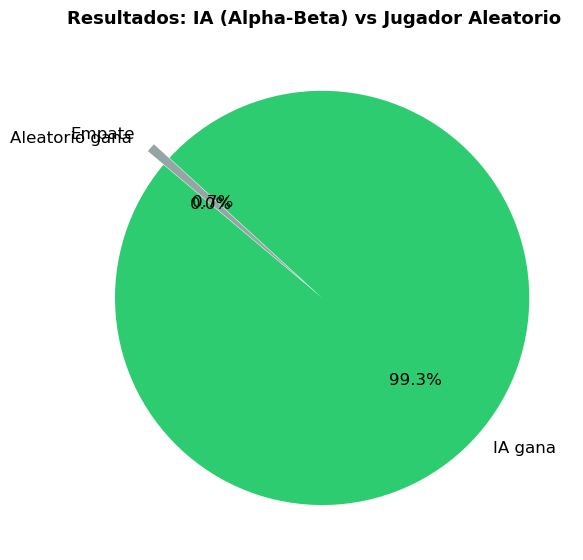

In [9]:
random.seed(42)
N_GAMES = 1000
resultados_100 = {'X': 0, 'O': 0, None: 0}  # X=IA, O=Aleatorio

for _ in range(N_GAMES):
    w = play_game(ai_player='X', verbose=False)
    resultados_100[w] += 1

gana_ia  = resultados_100['X']
empates  = resultados_100[None]
gana_alz = resultados_100['O']

print(f"=== {N_GAMES} partidas: IA (Alpha-Beta, X) vs Aleatorio (O) ===")
print(f"  IA gana      : {gana_ia:>5}  ({gana_ia/N_GAMES*100:.1f}%)")
print(f"  Empates      : {empates:>5}  ({empates/N_GAMES*100:.1f}%)")
print(f"  Aleatorio gana: {gana_alz:>4}  ({gana_alz/N_GAMES*100:.1f}%)")

# Gráfico de torta
fig, ax = plt.subplots(figsize=(6, 6))
labels   = ['IA gana', 'Empate', 'Aleatorio gana']
sizes    = [gana_ia, empates, gana_alz]
colors   = ['#2ecc71', '#95a5a6', '#e74c3c']
explode  = (0.05, 0.05, 0.05)
ax.pie(sizes, labels=labels, colors=colors, explode=explode,
       autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
ax.set_title('Resultados: IA (Alpha-Beta) vs Jugador Aleatorio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## ⏱️ Paso 8: Minimax con profundidad limitada

Para juegos más complejos (ajedrez, Go) donde el árbol es demasiado grande para explorarse completamente, se usa **Minimax con profundidad limitada** (`depth_limit`) combinado con una **función de evaluación** que estima la utilidad en estados no terminales.

Este concepto es la base de motores como **Stockfish** (ajedrez).

In [10]:
def eval_heuristic(state):
    """
    Función de evaluación heurística para Tic-Tac-Toe (estado no terminal).
    Cuenta líneas potenciales para cada jugador.
    """
    score = 0
    for a, b, c in WIN_LINES:
        line = [state[a], state[b], state[c]]
        x_count = line.count('X')
        o_count = line.count('O')
        if o_count == 0:  # línea disponible para X
            score += x_count
        if x_count == 0:  # línea disponible para O
            score -= o_count
    return score


def minimax_limited(state, maximize, depth, counter):
    """
    Minimax con límite de profundidad y función de evaluación.
    """
    counter[0] += 1

    if is_terminal(state):
        return utility(state) * 100, None  # amplificamos para priorizar victorias reales
    if depth == 0:
        return eval_heuristic(state), None  # evaluación heurística

    player = 'X' if maximize else 'O'
    ms = get_moves(state)

    if maximize:
        best_val, best_move = float('-inf'), None
        for m in ms:
            val, _ = minimax_limited(apply_move(state, m, player), False, depth-1, counter)
            if val > best_val:
                best_val, best_move = val, m
        return best_val, best_move
    else:
        best_val, best_move = float('inf'), None
        for m in ms:
            val, _ = minimax_limited(apply_move(state, m, player), True, depth-1, counter)
            if val < best_val:
                best_val, best_move = val, m
        return best_val, best_move


# Comparar nodos explorados con distintos límites de profundidad
print("Nodos explorados según límite de profundidad (desde tablero vacío):")
print(f"{'Límite':>8} | {'Nodos':>10} | {'Movimiento':>12}")
print("-" * 38)
for depth in [1, 2, 3, 4, 9]:
    c = [0]
    _, mv = minimax_limited(EMPTY, True, depth, c)
    label = "(completo)" if depth == 9 else ""
    print(f"{depth:>8} | {c[0]:>10,} | pos {mv:>2}  {label}")

Nodos explorados según límite de profundidad (desde tablero vacío):
  Límite |      Nodos |   Movimiento
--------------------------------------
       1 |         10 | pos  4  
       2 |         82 | pos  4  
       3 |        586 | pos  4  
       4 |      3,610 | pos  4  
       9 |    549,946 | pos  0  (completo)


## 🎓 Resumen y Conclusiones

### Puntos clave

1. **Minimax** garantiza juego óptimo en juegos de suma cero, pero explora el árbol completo — inviable para juegos complejos.
2. **Alpha-Beta Pruning** produce *exactamente* el mismo resultado que Minimax pero poda ramas irrelevantes, reduciendo los nodos explorados hasta un **97%** en tablero vacío de Tic-Tac-Toe.
3. La reducción es $O(b^{d/2})$ en el mejor caso vs $O(b^d)$ de Minimax — equivale a **duplicar la profundidad** alcanzable con el mismo cómputo.
4. Una IA con Alpha-Beta **nunca pierde** contra un jugador aleatorio en Tic-Tac-Toe (solo gana o empata).
5. Para juegos más complejos se agrega **límite de profundidad** + **función de evaluación heurística** (base de motores como Stockfish).

### 🚀 ¿Qué sigue?

- **Monte Carlo Tree Search (MCTS)**: alternativa probabilística, usada en AlphaGo.
- **Juegos con información imperfecta**: póquer, bridge — requieren modelos probabilísticos.
- **Juegos cooperativos**: los agentes no son adversarios sino aliados.

### 📚 Referencias

- Russell & Norvig — *Artificial Intelligence: A Modern Approach* (4th ed.), Cap. 5.
- Knuth, D. E. & Moore, R. W. (1975). *An Analysis of Alpha-Beta Pruning*. Artificial Intelligence, 6(4), 293–326.
- Sutton & Barto — *Reinforcement Learning: An Introduction*, Cap. 1 (context on agents).

---

*© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER*  
[![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/4.0/88x31.png)](https://creativecommons.org/licenses/by-sa/4.0/)